# Theme: Transformer - Scaled Dot-Product Attention 실습

이 노트북에서는 트랜스포머(Transformer) 아키텍처의 가장 중요한 심장부인 **Scaled Dot-Product Attention**의 동작 원리를 코드로 직접 구현하고, 단어 간의 관계(Attention Weights)를 시각화하여 동작 직관을 얻습니다.

### 학습 목표
1. **Query(Q), Key(K), Value(V)** 텐서 간의 행렬 연산 구조 이해
2. **Scaling Factor($\sqrt{d_k}$)**가 필요한 통계적 이유 이해
3. PyTorch를 사용해 Scaled Dot-Product Attention 모듈 구현
4. 어텐션 가중치(Attention Map)를 히트맵으로 시각화하여 단어 간 맥락 파악

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지 및 스타일 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style="whitegrid")

---
## 1. Scaled Dot-Product Attention 구현

수식:
$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

* **$QK^T$**: Query와 모든 Key의 유사도(내적)를 구합니다.
* **$/\sqrt{d_k}$**: 임베딩 차원($d_k$)이 커질수록 내적값이 극단적으로 커져 소프트맥스의 기울기가 소실(Vanishing Gradient)되는 것을 방지하기 위해 스케일링을 수행합니다.
* **$\text{softmax}$**: 유사도 점수를 합이 1이 되는 확률 분포(어텐션 가중치)로 변환합니다.
* **$\times V$**: 가중치를 실제 정보(Value)에 곱하여 가중합된 맥락 벡터(Context Vector)를 얻습니다.

In [2]:
class ScaledDotProductAttention(nn.Module):
    def __init__(self):
        super(ScaledDotProductAttention, self).__init__()
        
    def forward(self, Q, K, V, mask=None):
        # Q, K, V의 차원: [Batch_size, Sequence_Length, Embedding_Dimension]
        # 예: [1, 4, 8] -> 배치 크기 1, 단어 개수 4개, 임베딩 차원 8
        d_k = Q.size(-1)  # 임베딩 차원수
        
        # 1. Q와 K^T의 내적 연산 (Matmul)
        # K.transpose(-2, -1)을 통해 Key 행렬의 전치를 구해 곱해줍니다.
        # [Batch, Seq_len, d_k] x [Batch, d_k, Seq_len] -> [Batch, Seq_len, Seq_len]
        scores = torch.matmul(Q, K.transpose(-2, -1))
        
        # 2. Scaling
        scores = scores / np.sqrt(d_k)
        
        # 마스크(Mask) 적용 (디코더의 경우 미래 단어를 가릴 때 사용)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
            
        # 3. Softmax를 통과시켜 가중치 도출
        # 행의 합이 1이 되도록 마지막 차원에 softmax를 취함
        attn_weights = F.softmax(scores, dim=-1)
        
        # 4. 가중치를 Value 벡터에 곱함
        # [Batch, Seq_len, Seq_len] x [Batch, Seq_len, d_v] -> [Batch, Seq_len, d_v]
        context = torch.matmul(attn_weights, V)
        
        return context, attn_weights

---
## 2. 모의 데이터로 어텐션 동작 확인하기

다음의 가상 문장을 분석한다고 가정합니다.
* 문장: **"I study deep learning"** (단어 4개)
* 각 단어를 8차원의 임베딩 벡터로 설정합니다 ($d_k = 8$).

In [3]:
# 단어 리스트 정의
words = ["I", "study", "deep", "learning"]
seq_len = len(words)
d_k = 8

# 재현성을 위한 시드 설정 및 가상 임베딩 벡터 생성
torch.manual_seed(42)

# 텐서 크기: [Batch_size=1, Seq_len=4, d_k=8]
Q = torch.randn(1, seq_len, d_k)
K = torch.randn(1, seq_len, d_k)
V = torch.randn(1, seq_len, d_k)

print("Query Tensor Size:", Q.shape)
print("Key Tensor Size:", K.shape)
print("Value Tensor Size:", V.shape)

Query Tensor Size: torch.Size([1, 4, 8])
Key Tensor Size: torch.Size([1, 4, 8])
Value Tensor Size: torch.Size([1, 4, 8])


### 어텐션 연산 수행

In [4]:
attention_layer = ScaledDotProductAttention()
context, attn_weights = attention_layer(Q, K, V)

print("Context Vector (맥락이 반영된 출력 벡터) Size:", context.shape)
print("Attention Weights (가중치 맵) Size:", attn_weights.shape)
print("\n첫 번째 배치의 가중치 행렬:\n", attn_weights[0].detach().numpy())

Context Vector (맥락이 반영된 출력 벡터) Size: torch.Size([1, 4, 8])
Attention Weights (가중치 맵) Size: torch.Size([1, 4, 4])

첫 번째 배치의 가중치 행렬:
 [[0.19424005 0.4102347  0.32415748 0.0713677 ]
 [0.04075206 0.65554816 0.0863854  0.21731433]
 [0.10405151 0.2057392  0.18241791 0.5077914 ]
 [0.19263689 0.18032306 0.19547567 0.43156436]]


---
## 3. 어텐션 가중치(Attention Map) 시각화

어텐션 맵은 모델이 각 단어를 인코딩할 때 문장 속 다른 어떤 단어에 초점을 맞추었는지를 2차원 히트맵으로 보여줍니다.

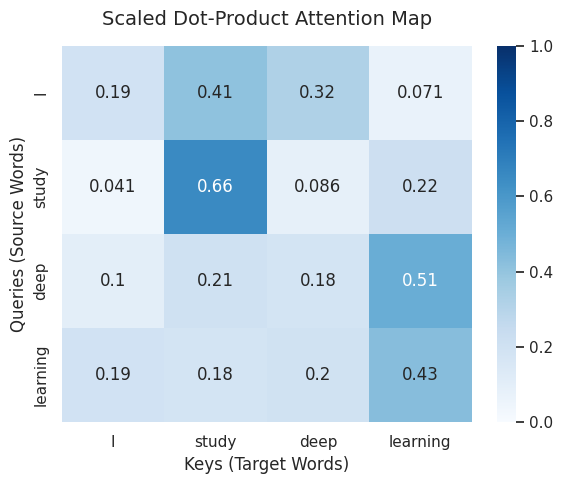

In [5]:
def plot_attention_map(attn_weights, words):
    # Batch 차원을 떼어냄 [Seq_len, Seq_len]
    matrix = attn_weights[0].detach().numpy()
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        matrix, 
        xticklabels=words, 
        yticklabels=words, 
        annot=True, 
        cmap="Blues", 
        cbar=True, 
        vmin=0, 
        vmax=1
    )
    
    plt.title("Scaled Dot-Product Attention Map", fontsize=14, pad=15)
    plt.xlabel("Keys (Target Words)", fontsize=12)
    plt.ylabel("Queries (Source Words)", fontsize=12)
    plt.tight_layout()
    plt.show()

plot_attention_map(attn_weights, words)

### 💡 결과 분석 및 생각해보기

1. **가로축(Keys)**과 **세로축(Queries)**:
   * 예컨대 세로축의 `study` 행의 값을 보면, 모델이 `study`라는 단어를 이해할 때 `I`, `study`, `deep`, `learning`에 각각 몇 %의 가중치를 나누어 주었는지 확인할 수 있습니다.
   * 각 행(Row)의 값들의 합을 더해보면 소프트맥스 결과이므로 정확히 `1.0`이 되는 것을 알 수 있습니다.

2. **Scaling이 없다면 어떻게 될까?**:
   * 아래 셀에서 스케일링 팩터($\sqrt{d_k}$)가 적용되지 않은 순수 Dot-Product Attention을 시각화해보고 어떤 차이가 생기는지 직접 확인해 봅니다.

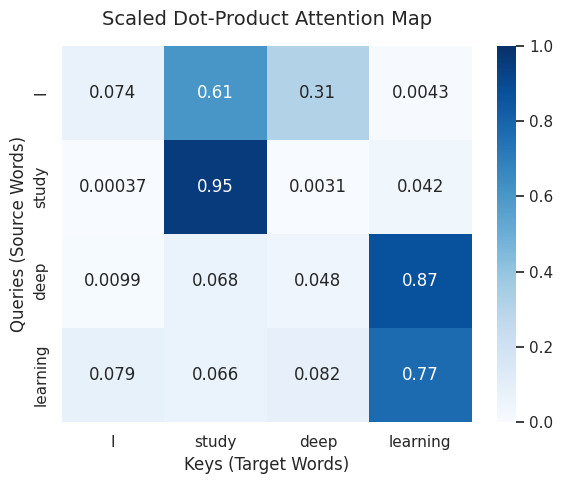

In [6]:
class PureDotProductAttention(nn.Module):
    def forward(self, Q, K, V):
        # Scaling이 제외된 내적
        scores = torch.matmul(Q, K.transpose(-2, -1))
        attn_weights = F.softmax(scores, dim=-1)
        context = torch.matmul(attn_weights, V)
        return context, attn_weights

# Scaling이 없을 때의 어텐션 맵 확인
pure_attention = PureDotProductAttention()
_, pure_attn_weights = pure_attention(Q, K, V)
plot_attention_map(pure_attn_weights, words)